In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df=pd.read_csv(r"C:\Users\shreyaash mogaveera\loan-default-risk-predictor\data\application_train.csv")

In [37]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
df.shape

(307511, 122)

In [39]:
df['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [40]:
df['TARGET'].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

### 91% have repaid and only 8% have defaulted

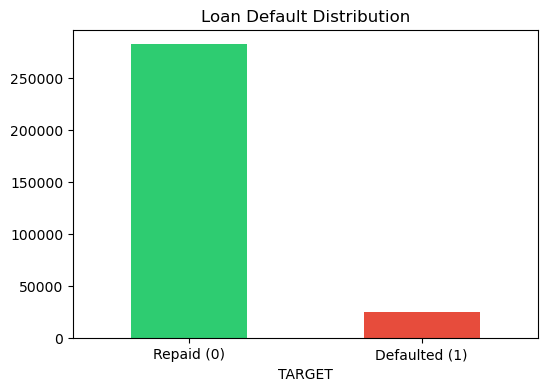

In [41]:
fig,ax=plt.subplots(figsize=(6,4))
df['TARGET'].value_counts().plot(kind='bar',color=['#2ecc71','#e74c3c'],ax=ax)
ax.set_title("Loan Default Distribution")
ax.set_xticklabels(['Repaid (0)','Defaulted (1)'],rotation=0)
plt.savefig('../assets/class_distribution.png',dpi=150,bbox_inches='tight')
plt.show()

In [42]:
#missing values
missing=df.isnull().sum()
missing_pct=(missing/len(df)*100).sort_values(ascending=False)
missing_pct[missing_pct>0].head(20)

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64

In [43]:
pip install fg-data-profiling

Note: you may need to restart the kernel to use updated packages.


In [44]:
from data_profiling import ProfileReport
profile=ProfileReport(df,minimal=True,title="Loan default EDA")
profile.to_file("eda_report.html")
print("saved")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|          | 0/122 [00:00<?, ?it/s]
%|          | 1/122 [00:00<01:32,  1.30it/s]
%|▏         | 2/122 [00:01<00:47,  2.50it/s]
%|▏         | 3/122 [00:01<01:01,  1.93it/s]
%|▎         | 4/122 [00:02<00:58,  2.02it/s]
%|▍         | 5/122 [00:03<01:38,  1.19it/s]
%|▍         | 6/122 [00:03<01:13,  1.57it/s]
%|▌         | 7/122 [00:03<00:55,  2.06it/s]
%|████▌     | 55/122 [00:04<00:01, 43.41it/s]
%|█████▋    | 69/122 [00:05<00:02, 26.05it/s]
%|██████▍   | 79/122 [00:06<00:01, 21.50it/s]
%|███████▏  | 87/122 [00:07<00:02, 15.64it/s]
%|███████▌  | 93/122 [00:08<00:02, 12.67it/s]
%|███████▉  | 97/122 [00:08<00:02, 11.66it/s]
%|████████▏ | 100/122 [00:08<00:01, 12.63it/s]
%|████████▍ | 103/122 [00:08<00:01, 13.70it/s]
%|████████▋ | 106/122 [00:08<00:01, 12.04it/s]
100%|██████████| 122/122 [00:09<00:00, 13.54it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

saved


In [45]:
#dropping high missing values
cols_to_drop=missing_pct[missing_pct>40].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns")
print(cols_to_drop)
df= df.drop(columns=cols_to_drop)

Dropping 49 columns
['COMMONAREA_AVG', 'COMMONAREA_MODE', 'COMMONAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE', 'FLOORSMIN_MODE', 'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'YEARS_BUILD_AVG', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'OWN_CAR_AGE', 'LANDAREA_MEDI', 'LANDAREA_AVG', 'LANDAREA_MODE', 'BASEMENTAREA_MODE', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_AVG', 'EXT_SOURCE_1', 'NONLIVINGAREA_MODE', 'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MEDI', 'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE', 'WALLSMATERIAL_MODE', 'APARTMENTS_AVG', 'APARTMENTS_MEDI', 'APARTMENTS_MODE', 'ENTRANCES_MODE', 'ENTRANCES_MEDI', 'ENTRANCES_AVG', 'LIVINGAREA_AVG', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE', 'HOUSETYPE_MODE', 'FLOORSMAX_MODE', 'FLOORSMAX_AVG', 'FLOORSMAX_MEDI', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_AVG', 'TOTALAREA_MODE', 

In [46]:
#dropping columns with low variance and just IDs
drop=['SK_ID_CURR','WEEKDAY_APPR_PROCESS_START','HOUR_APPR_PROCESS_START',
     'FLAG_MOBIL','FLAG_EMP_PHONE','FLAG_WORK_PHONE','FLAG_CONT_MOBILE',
     'FLAG_PHONE','FLAG_EMAIL']
df=df.drop(columns=[c for c in drop if c in df.columns])

In [47]:
df.shape

(307511, 64)

In [48]:
#checking correlation with TARGET
num_cols=df.select_dtypes(include='number').columns.tolist()
num_cols.remove('TARGET')

corr_with_target= df[num_cols].corrwith(df['TARGET']).abs().sort_values(ascending=False)

print("Top 20 features correlating with target:")
print(corr_with_target.head(20))

print("\nBottom features (not much coorelation:")
print(corr_with_target.tail(20))

Top 20 features correlating with target:
EXT_SOURCE_3                   0.178919
EXT_SOURCE_2                   0.160472
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_EMPLOYED                  0.044932
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
DAYS_REGISTRATION              0.041975
AMT_GOODS_PRICE                0.039645
REGION_POPULATION_RELATIVE     0.037227
LIVE_CITY_NOT_WORK_CITY        0.032518
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
AMT_CREDIT                     0.030369
FLAG_DOCUMENT_6                0.028602
AMT_REQ_CREDIT_BUREAU_YEAR     0.019930
dtype: float64

Bottom features (not much coorelation:
FLAG_DOCUMENT_15               0.006536
REG_REGION_NOT_LIVE_REGION     0.005576
FLAG_DOCUMENT_2         

In [49]:
low_corr=corr_with_target[corr_with_target<0.01].index.tolist()
print(f"\n{len(low_corr)} features with <1% correlation")


27 features with <1% correlation


In [51]:
#dropping featues that barely change across rows (low variance features)
from sklearn.feature_selection import VarianceThreshold
selector=VarianceThreshold(threshold=0.01)
selector.fit(df[num_cols].fillna(0))
low_var=[col for col,var in zip(num_cols,selector.variances_) if var<0.01]
print(f"Low variance features: {low_var}")

Low variance features: ['REGION_POPULATION_RELATIVE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR']


In [52]:
df=df.drop(columns=[c for c in low_var if c in df.columns])

In [53]:
df.shape

(307511, 46)

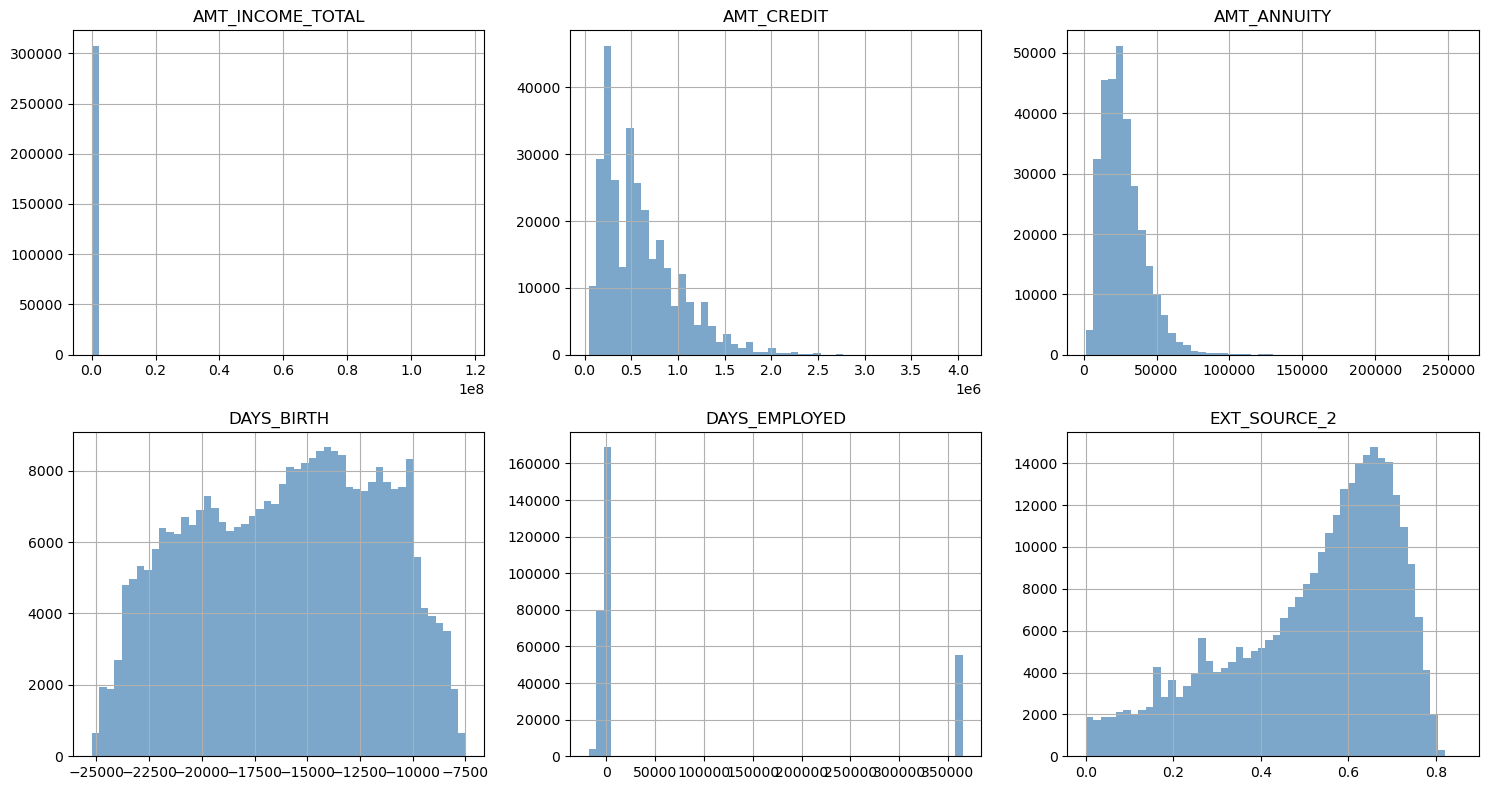

In [55]:
#key feature distribution
fig,axes=plt.subplots(2,3, figsize=(15,8))
features=['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','DAYS_BIRTH','DAYS_EMPLOYED','EXT_SOURCE_2']

for i,feat in enumerate(features):
    ax=axes[i//3][i%3]
    df[feat].hist(bins=50,ax=ax,color='steelblue',alpha=0.7)
    ax.set_title(feat)

plt.tight_layout()
plt.savefig('../assets/feature_distributions.png',dpi=150)
plt.show()

In [56]:
df['DAYS_EMPLOYED'].max()

365243

## KEY INSIGHTS
- dataset is imbalanced (8% default)
- DAYS_EMPLOYED has a big value 365243
      - must replace with 0
- EXT_SOURCE_2 and EXT_SOURCE_3 are strong negative predictors (high score= less likely to default)
- AMT_CREDIT, AMT_INCOME_TOTAL and AMT_ANNUITY are right skewed